# Hospital Patient Readmission & Resource Utilization Analysis

## 1. Import Required Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [53]:
df = pd.read_csv("../Dataset/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Load Dataset

In [54]:
df.shape

(101766, 50)

In [55]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [57]:
df.describe

<bound method NDFrame.describe of         encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        Caucasian    Male  [70-80)      ?   

        admission_type_id  di

In [58]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
print ("Rows :", df.shape[0])
print ("Columns :", df.shape[1])

Rows : 101766
Columns : 50


In [61]:
df.duplicated().sum()


np.int64(0)

## 3. Data Understanding

In [62]:
hospital_df =df.copy()

In [63]:
hospital_df.replace("?" , np.nan, inplace=True)

In [64]:
hospital_df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [65]:
hospital_df.duplicated().sum()

np.int64(0)

In [66]:
hospital_df.shape 


(101766, 50)

In [67]:
hospital_df.duplicated().sum()

np.int64(0)

In [68]:
hospital_df.drop(columns=["weight"], inplace=True)

In [69]:
hospital_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [70]:
"weight" in hospital_df.columns

False

In [71]:
hospital_df.shape

(101766, 49)

In [72]:
hospital_df.head()


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 4. Data Cleaning

In [73]:
hospital_df[["race", "diag_1", "diag_2", "diag_3"]].isnull().sum()

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64

In [74]:
hospital_df["race"] = hospital_df["race"].fillna("Unknown")

hospital_df["diag_1"] = hospital_df["diag_1"].fillna("Unknown")
hospital_df["diag_2"] = hospital_df["diag_2"].fillna("Unknown") 
hospital_df["diag_3"] = hospital_df["diag_3"].fillna("Unknown")

In [75]:
hospital_df[["race", "diag_1", "diag_2", "diag_3"]].isnull().sum()

race      0
diag_1    0
diag_2    0
diag_3    0
dtype: int64

## 5. Feature Engineering

In [76]:
hospital_df["age"].unique()

array(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)'], dtype=object)

In [77]:
hospital_df["Age_Group"] = hospital_df["age"]

In [78]:
hospital_df[["age", "Age_Group"]].head()

,age,Age_Group
0,[0-10),[0-10)
1,[10-20),[10-20)
2,[20-30),[20-30)
3,[30-40),[30-40)
4,[40-50),[40-50)


In [79]:
hospital_df["Readmitted"] = hospital_df["readmitted"].apply(
    lambda x: "Yes" if x == "<30" else "No"
)

In [80]:
hospital_df["Readmitted"].value_counts()

Readmitted
No     90409
Yes    11357
Name: count, dtype: int64

In [81]:
hospital_df.rename(
    columns={"time_in_hospital": "Length_of_Stay"},
    inplace=True
)

In [82]:
hospital_df[["Length_of_Stay"]].head()

,Length_of_Stay
0,1
1,3
2,2
3,2
4,1


In [83]:
hospital_df["Estimated_Cost"] = (
    hospital_df["Length_of_Stay"] * 6000
    + hospital_df["num_medications"] * 500
)

In [84]:
hospital_df[
    ["Length_of_Stay", "num_medications", "Estimated_Cost"]
].head()

,Length_of_Stay,num_medications,Estimated_Cost
0,1,1,6500
1,3,18,27000
2,2,13,18500
3,2,16,20000
4,1,8,10000


## 6. Exploratory Data Analysis (EDA)


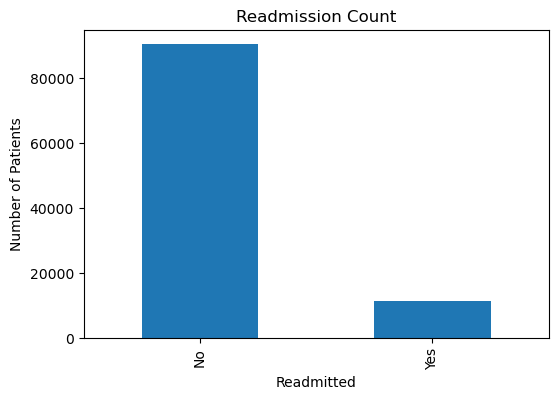

In [85]:
import matplotlib.pyplot as plt

hospital_df["Readmitted"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Readmission Count")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.show()

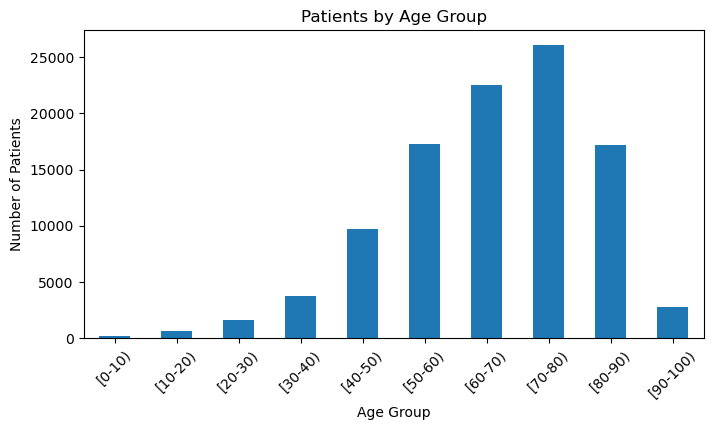

In [86]:
hospital_df["Age_Group"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

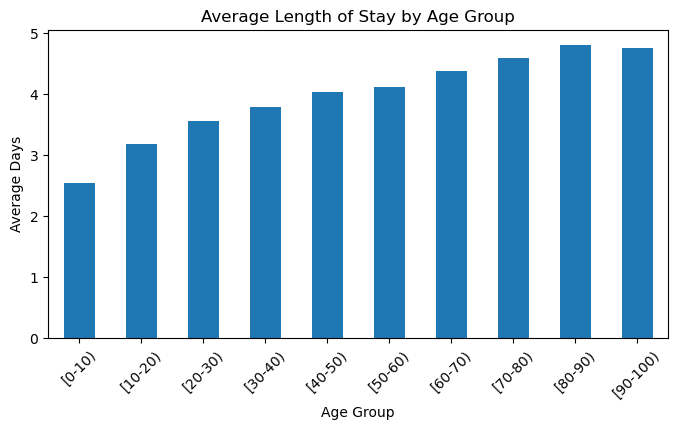

In [87]:
hospital_df.groupby("Age_Group")["Length_of_Stay"].mean().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Average Length of Stay by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Days")
plt.xticks(rotation=45)

plt.show()

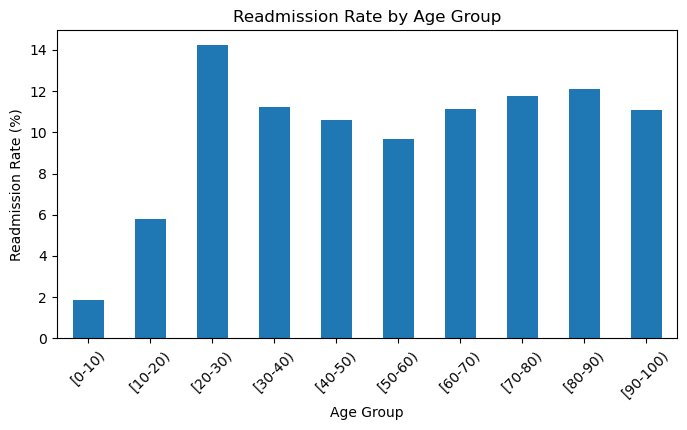

In [88]:
readmission_by_age = (
    hospital_df.groupby("Age_Group")["Readmitted"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8,4))
readmission_by_age.plot(kind="bar")

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

<Figure size 800x500 with 0 Axes>

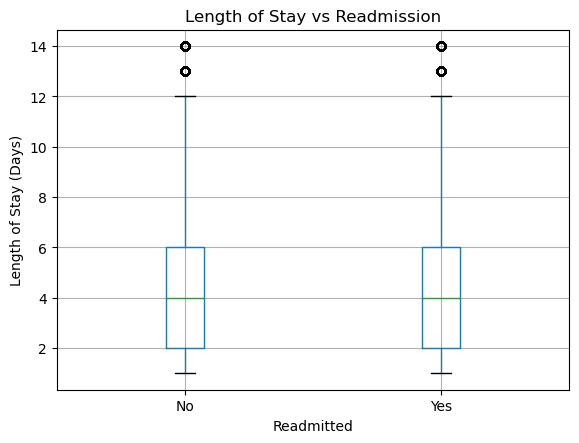

In [89]:
plt.figure(figsize=(8,5))

hospital_df.boxplot(
    column="Length_of_Stay",
    by="Readmitted"
)

plt.title("Length of Stay vs Readmission")
plt.suptitle("")
plt.xlabel("Readmitted")
plt.ylabel("Length of Stay (Days)")

plt.show()

In [90]:
hospital_df.to_csv("../Dataset/clean_hospital_data.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [91]:
hospital_df["diag_1"].head(10)

0    250.83
1       276
2       648
3         8
4       197
5       414
6       414
7       428
8       398
9       434
Name: diag_1, dtype: object

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [93]:
df = pd.read_csv("../Dataset/diabetic_data.csv")
hospital_df = df.copy()


In [94]:
hospital_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [95]:
df = pd.read_csv("../Dataset/diabetic_data.csv")
hospital_df = df.copy()

In [96]:
import pandas as pd

hospital_df = pd.read_csv("../Dataset/clean_hospital_data.csv")

C:\Users\jayes\AppData\Local\Temp\ipykernel_24672\2330594441.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  hospital_df = pd.read_csv("../Dataset/clean_hospital_data.csv")


In [97]:
 hospital_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'Length_of_Stay', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'Age_Group', 'Readmitted', 'Estimated_Cost'],
      dtype='object')

In [98]:
hospital_df["diag_1"].head(10)

0    250.83
1       276
2       648
3         8
4       197
5       414
6       414
7       428
8       398
9       434
Name: diag_1, dtype: object

In [99]:
def get_disease(code):
    return "Diabetes"

In [100]:
pip install pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [102]:
df = pd.read_csv("../data/hospital_readmissions.csv")
hospital_df = df.copy()

FileNotFoundError: [Errno 2] No such file or directory: '../data/hospital_readmissions.csv'

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./Dataset/diabetic_data.csv")
hospital_df = df.copy()

hospital_df.head()

FileNotFoundError: [Errno 2] No such file or directory: './Dataset/diabetic_data.csv'

In [107]:
df = pd.read_csv("./Dataset/diabetic_data.csv")
hospital_df = df.copy()

FileNotFoundError: [Errno 2] No such file or directory: './Dataset/diabetic_data.csv'

In [108]:
 df = pd.read_csv("diabetic_data.csv")
hospital_df = df.copy()

IndentationError: unexpected indent (3616811610.py, line 1)

In [109]:
import pandas as pd

df = pd.read_csv(r"Dataset\diabetic_data.csv")
hospital_df = df.copy()

hospital_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset\\diabetic_data.csv'

In [110]:
import os

print(os.getcwd())

c:\Data analytics project\Hospital Readmission Analysis\Python


In [111]:
import pandas as pd

df = pd.read_csv(r"..\Dataset\diabetic_data.csv")
hospital_df = df.copy()

hospital_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [112]:
hospital_df["diag_1"].head(20)

0     250.83
1        276
2        648
3          8
4        197
5        414
6        414
7        428
8        398
9        434
10     250.7
11       157
12       428
13       428
14       518
15       999
16       410
17       682
18       402
19       737
Name: diag_1, dtype: object

In [113]:
hospital_df["diag_1"].unique()[:20]


array(['250.83', '276', '648', '8', '197', '414', '428', '398', '434',
       '250.7', '157', '518', '999', '410', '682', '402', '737', '572',
       'V57', '189'], dtype=object)

In [114]:
hospital_df["diag_1"].unique()[:20]


array(['250.83', '276', '648', '8', '197', '414', '428', '398', '434',
       '250.7', '157', '518', '999', '410', '682', '402', '737', '572',
       'V57', '189'], dtype=object)

In [115]:
hospital_df["diag_1"].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

In [116]:
hospital_df["diag_2"].value_counts().head(20)

diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
250.01    1523
285       1520
780       1491
425       1434
682       1433
Name: count, dtype: int64

## Disease Category Analysis


In [117]:
hospital_df[["diag_1", "diag_2", "diag_3"]].head(10)

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [118]:
hospital_df["diag_1"].dtype

dtype('O')

In [119]:
hospital_df["diag_1"].dtype

dtype('O')

## Disease Category Mapping


In [120]:
hospital_df["diag_1"].head(10)

0    250.83
1       276
2       648
3         8
4       197
5       414
6       414
7       428
8       398
9       434
Name: diag_1, dtype: object

In [121]:
hospital_df["diag_1"].head(10)

0    250.83
1       276
2       648
3         8
4       197
5       414
6       414
7       428
8       398
9       434
Name: diag_1, dtype: object

In [122]:
hospital_df["diag_1"] = hospital_df["diag_1"].astype(str)

In [123]:
hospital_df["diag_1"].str.startswith("250").head(10)

0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: diag_1, dtype: bool

In [124]:
def disease_category(code):

    if code.startswith("250"):
        return "Diabetes"

    elif code.startswith(("390","391","392","393","394","395","396","397","398",
                          "399","400","401","402","403","404","405","410","411",
                          "412","413","414","415","416","417","418","419","420",
                          "421","422","423","424","425","426","427","428","429")):
        return "Heart Disease"

    elif code.startswith(("580","581","582","583","584","585","586","587","588","589")):
        return "Kidney Disease"

    elif code.startswith(("460","461","462","463","464","465","466","467","468",
                          "469","470","471","472","473","474","475","476","477",
                          "478","479","480","481","482","483","484","485","486",
                          "487","488","489","490","491","492","493","494","495",
                          "496","497","498","499")):
        return "Respiratory Disease"

    else:
        return "Other"

In [125]:
hospital_df["Disease_Category"] = hospital_df["diag_1"].apply(disease_category)

In [126]:
hospital_df["Disease_Category"] = hospital_df["diag_1"].apply(disease_category)

In [127]:
hospital_df[["diag_1","Disease_Category"]].head(20)

,diag_1,Disease_Category
0,250.83,Diabetes
1,276,Other
2,648,Other
3,8,Other
4,197,Other
5,414,Heart Disease
6,414,Heart Disease
7,428,Heart Disease
8,398,Heart Disease
9,434,Other


In [128]:
disease_count = hospital_df["Disease_Category"].value_counts()

print(disease_count)

Disease_Category
Other                  60061
Heart Disease          23240
Diabetes                8757
Respiratory Disease     8055
Kidney Disease          1653
Name: count, dtype: int64


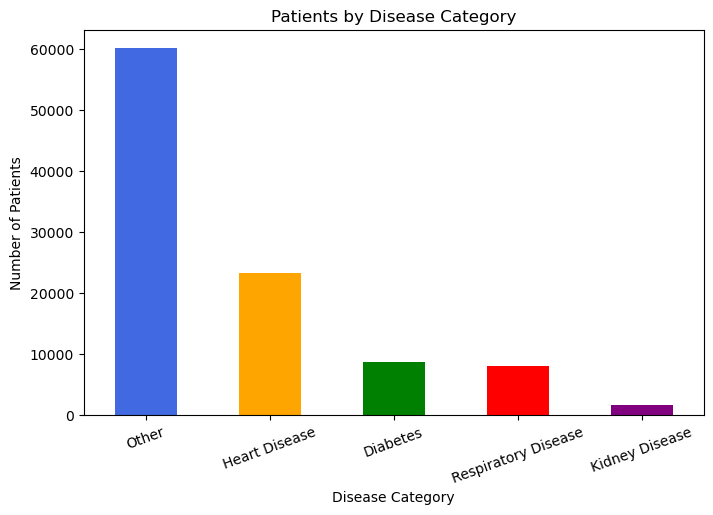

In [129]:
plt.figure(figsize=(8,5))

disease_count.plot(
    kind="bar",
    color=["royalblue", "orange", "green", "red", "purple"]
)

plt.title("Patients by Disease Category")
plt.xlabel("Disease Category")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.show()

In [130]:
readmission = hospital_df.groupby("Disease_Category")["Readmitted"].mean() * 100

print(readmission)

KeyError: 'Column not found: Readmitted'

In [131]:
hospital_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'Disease_Category'],
      dtype='object')

In [132]:
hospital_df["Readmitted"] = hospital_df["readmitted"].map({
    "NO": 0,
    "<30": 1,
    ">30": 1
})

In [133]:
hospital_df[["readmitted", "Readmitted"]].head(10)

,readmitted,Readmitted
0,NO,0
1,>30,1
2,NO,0
3,NO,0
4,NO,0
5,>30,1
6,NO,0
7,>30,1
8,NO,0
9,NO,0


In [134]:
readmission = hospital_df.groupby("Disease_Category")["Readmitted"].mean() * 100

print(readmission)

Disease_Category
Diabetes               50.873587
Heart Disease          47.581756
Kidney Disease         48.457350
Other                  43.888713
Respiratory Disease    52.489137
Name: Readmitted, dtype: float64


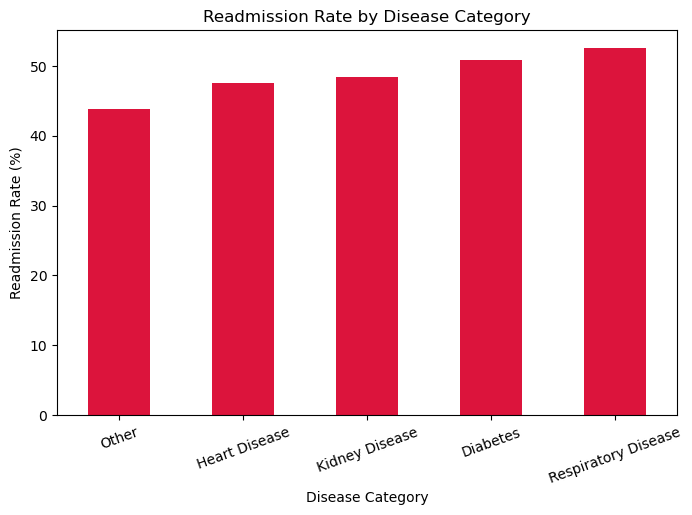

In [135]:
plt.figure(figsize=(8,5))

readmission.sort_values().plot(
    kind="bar",
    color="crimson"
)

plt.title("Readmission Rate by Disease Category")
plt.xlabel("Disease Category")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [136]:
avg_cost = hospital_df.groupby("Disease_Category")["Estimated_Cost"].mean()
print(avg_cost)

KeyError: 'Column not found: Estimated_Cost'

In [137]:
 hospital_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'Disease_Category', 'Readmitted'],
      dtype='object')

In [138]:
print(hospital_df.columns)


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'Disease_Category', 'Readmitted'],
      dtype='object')


In [139]:
hospital_df["Estimated_Cost"] = (
    hospital_df["Length_of_Stay"] * 6000
    + hospital_df["num_medications"] * 500
)

KeyError: 'Length_of_Stay'

In [ ]:
hospital_df["Estimated_Cost"] = (
    hospital_df["time_in_hospital"] * 6000
    + hospital_df["num_medications"] * 500
)

In [140]:
hospital_df[["time_in_hospital", "num_medications", "Estimated_Cost"]].head()

KeyError: "['Estimated_Cost'] not in index"

In [141]:
avg_cost = hospital_df.groupby("Disease_Category")["Estimated_Cost"].mean()

print(avg_cost)

KeyError: 'Column not found: Estimated_Cost'

In [142]:
plt.figure(figsize=(8,5))

avg_cost.plot(kind="bar", color=["blue","orange","green","red","purple"])

plt.title("Average Estimated Cost by Disease")
plt.xlabel("Disease Category")
plt.ylabel("Average Cost")

plt.show()

NameError: name 'avg_cost' is not defined

<Figure size 800x500 with 0 Axes>

In [143]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

X = hospital_df[features]
y = hospital_df["Readmitted"]

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
from sklearn.model_selection import train_test_split

In [147]:
import sys

print(sys.executable)

c:\Users\jayes\anaconda3\python.exe


In [148]:
import sklearn
print(sklearn.__version__)

1.9.0


In [149]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)  

NameError: name 'x' is not defined

In [150]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

X = hospital_df[features]
y = hospital_df["Readmitted"]

In [154]:
import pandas as pd

hospital_df = pd.read_csv("Dataset/diabetic_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/diabetic_data.csv'

In [156]:
pd.read_csv("Dataset/Diabetic_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/Diabetic_data.csv'

In [157]:
import os
print(os.getcwd)
print(os.listdir())

<built-in function getcwd>
['01_Data_Cleaning.ipynb']


In [159]:
import os
print(os.getcwd())

c:\Data analytics project\Hospital Readmission Analysis\Python


In [160]:
import pandas as pd

hospital_df = pd.read_csv("../Dataset/diabetic_data.csv")
print(hospital_df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital payer_code         medical_specialty  num_lab_procedures  \
0                 1          ?  Pediatrics-Endocrinolo

In [162]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

X = hospital_df[features]
y = hospital_df["readmitted"]

In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(81412, 7)
(20354, 7)


In [164]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [165]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5674560282991058


In [166]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   17   632  1636]
 [   15  1523  5579]
 [    5   937 10010]]


In [167]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         <30       0.46      0.01      0.01      2285
         >30       0.49      0.21      0.30      7117
          NO       0.58      0.91      0.71     10952

    accuracy                           0.57     20354
   macro avg       0.51      0.38      0.34     20354
weighted avg       0.54      0.57      0.49     20354



In [168]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print(importance)

              Feature  Coefficient
6    number_inpatient     0.205758
5    number_emergency     0.077606
0    time_in_hospital     0.017433
3     num_medications     0.005165
4   number_outpatient     0.004475
1  num_lab_procedures     0.000173
2      num_procedures    -0.012980
